# 🚀 Introdução à Visualização Gráfica

## O que é Visualização de Dados?

Visualização de dados é o processo de **transformar dados brutos (tabelas, números) em representações visuais** (gráficos, diagramas, plots) que permitem entender, explorar e comunicar padrões, tendências e insights de forma clara e eficiente. Isso facilita a análise e ajuda a contar histórias com os dados, o que é um elemento essencial dentro da análise exploratória de dados.

---

## Por que usar visualizações?

- Facilita a compreensão de grandes conjuntos de dados.
- Revela padrões, tendências e relações difíceis de ver em tabelas.
- É uma ferramenta essencial para comunicar resultados e construir **storytelling com dados**.

---

## Bibliotecas Python para Visualização

### 🧰 1. **Matplotlib**

- Biblioteca clássica de gráficos em Python.
- Permite criar muitos tipos de gráficos estáticos: linhas, barras, histogramas, dispersão etc.
- Base utilizada por muitas outras bibliotecas de visualização.

```bash
pip install matplotlib
```

---

### 🎨 2. **Seaborn**

* Construída sobre o Matplotlib, com interface de alto nível. ([Alura][1])
* Facilita a criação de gráficos estatísticos mais bonitos e expressivos com menos código. ([Alura][1])

```bash
pip install seaborn
```

---

### ⚡ 3. **Plotly**

* Biblioteca poderosa para gráficos **interativos** e exploráveis. ([Asimov Academy][2])
* Permite zoom, filtros e interatividade diretamente no notebook ou web. ([Asimov Academy][2])

```bash
pip install plotly
```

---

[1]: https://www.alura.com.br/artigos/data-visualization-conhecendo-bibliotecas-python?utm_source=chatgpt.com "Data Visualization: conhecendo as bibliotecas do Python - Alura"
[2]: https://hub.asimov.academy/blog/bibliotecas-python-visualizacao-de-dados/?utm_source=chatgpt.com "Bibliotecas Python para visualização de dados: quais usar?"


# 📊 Tabela vs Gráfico (Titanic)

## 📥 Carregar dados e ver tabela

Execute a célula de Python abaixo para carregar os dados e visualizar as primeiras linhas.

A tabela mostra os dados **como estão**: cada linha é um passageiro, e colunas como `survived`, `pclass`, `sex`, `age`, `fare` e outras podem ser vistas sem visualização.


In [275]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../Aula 2/basetitanicjhon.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,1,1,male,52.0,0,0,30.5000,S,First,man,True,C,Southampton,yes,True
1,1,2,female,33.0,1,2,27.7500,S,Second,woman,False,NaN,Southampton,yes,False
2,1,1,female,35.0,0,0,135.6333,S,First,woman,False,C,Southampton,yes,True
3,0,3,male,15.0,1,1,7.2292,C,Third,child,False,NaN,Cherbourg,no,False
4,1,3,male,NaN,0,0,8.1125,S,Third,man,True,NaN,Southampton,yes,True


## 📊 Gráfico para ver padrões

Aqui transformamos a tabela em gráfico pra enxergar padrões que **não aparecem só olhando a tabela**.

## Por exemplo, quantas pessoas sobreviveram vs morreram:

Execute a célula de Python abaixo para gerar o gráfico.


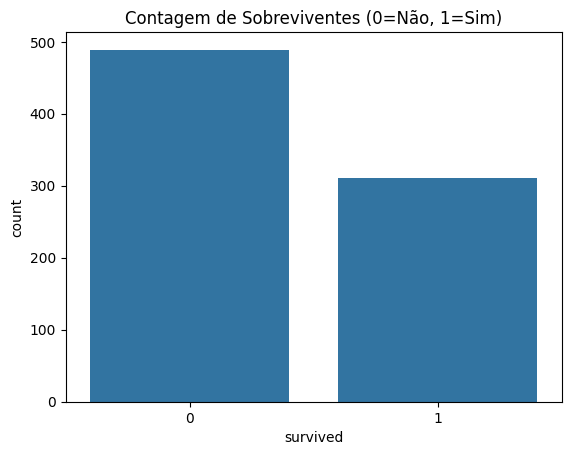

In [276]:
sns.countplot(x="survived", data=df)
plt.title("Contagem de Sobreviventes (0=Não, 1=Sim)")
plt.show()


## 📌 Porque isso importa

* A tabela mostra **valores individuais**.
* O gráfico **resume visualmente** a informação e expõe padrões rápidos (ex: mais pessoas morreram do que sobreviveram). ([GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/python-titanic-data-eda-using-seaborn/?utm_source=chatgpt.com))

---

## 📈 Outro gráfico: sobrevivência por gênero

Execute a célula de Python abaixo.


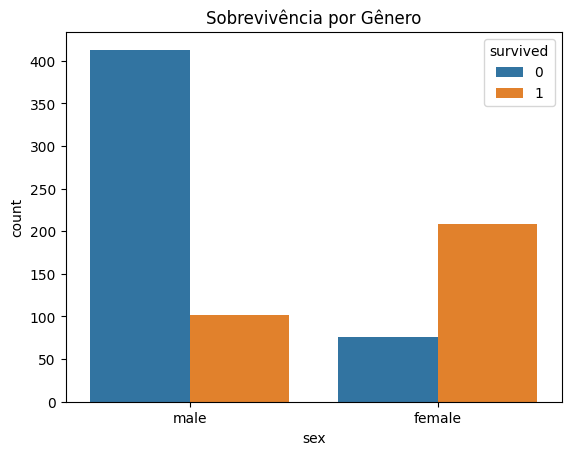

In [277]:
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Sobrevivência por Gênero")
plt.show()


## 🧠 Observações rápidas

* Gráficos ajudam a ver **comparações e proporções** num piscar de olhos. ([GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/python-titanic-data-eda-using-seaborn/?utm_source=chatgpt.com))
* Tabelas são ótimas para conferência dos dados, mas **não ajudam tanto a ver padrões rápidos**.

---


## 📌 3.1 Variáveis numéricas (contínuas)

👉 Mostram distribuição ou padrões de valores contínuos (ex.: `age`, `fare`).

### Histograma

Quando usar: **uma variável numérica isolada**.

Conta: **como os valores se distribuem** (moda, assimetria, possíveis outliers).


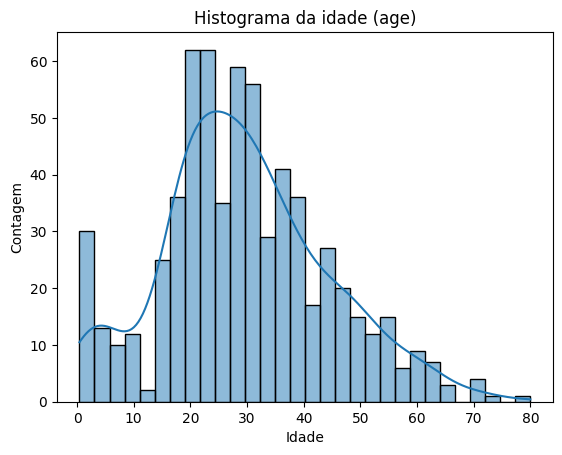

In [278]:
sns.histplot(data=df, x="age", bins=30, kde=True, stat="count")
plt.title("Histograma da idade (age)")
plt.xlabel("Idade")
plt.ylabel("Contagem")
plt.show()


### Boxplot

Boa pra **comparar distribuições entre grupos**.

Mostra **mediana, quartis e possíveis outliers**.


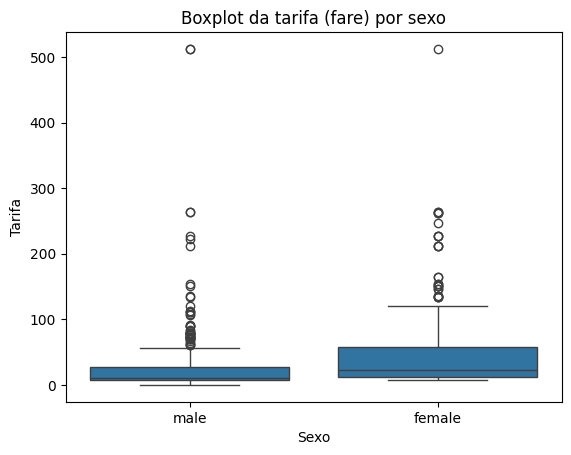

In [279]:
sns.boxplot(x="sex", y="fare", data=df)
plt.title("Boxplot da tarifa (fare) por sexo")
plt.xlabel("Sexo")
plt.ylabel("Tarifa")
plt.show()


### Exemplos ruins (para evitar)

- **Histograma com várias variáveis diferentes juntas** pode confundir, porque mistura escalas e formas.
- **Boxplot com muitas variáveis de escalas diferentes** esconde detalhes importantes (valores menores ficam “achatados”).
- **Scatter para mostrar distribuição de uma variável só** gera ruído visual e não mostra bem a frequência.


<Figure size 800x400 with 0 Axes>

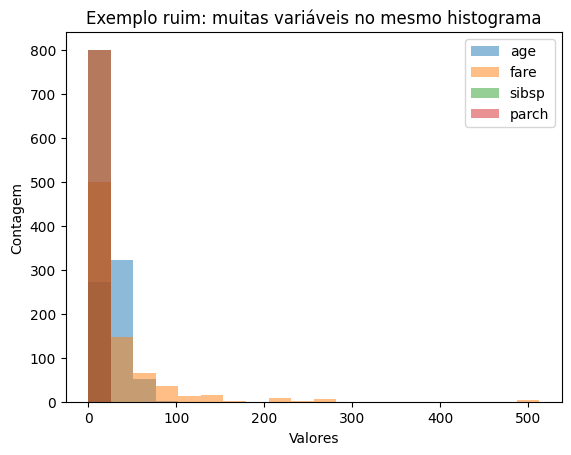

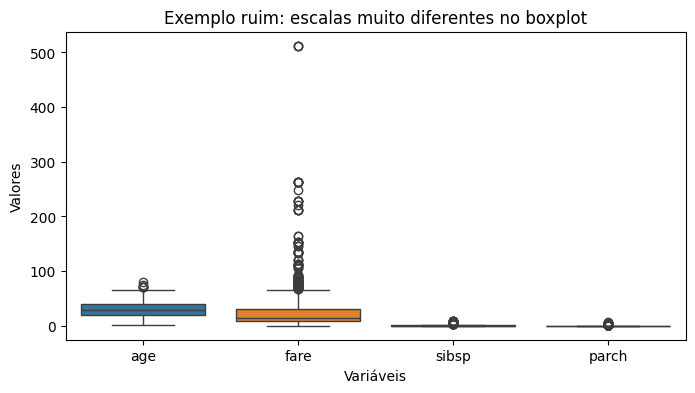

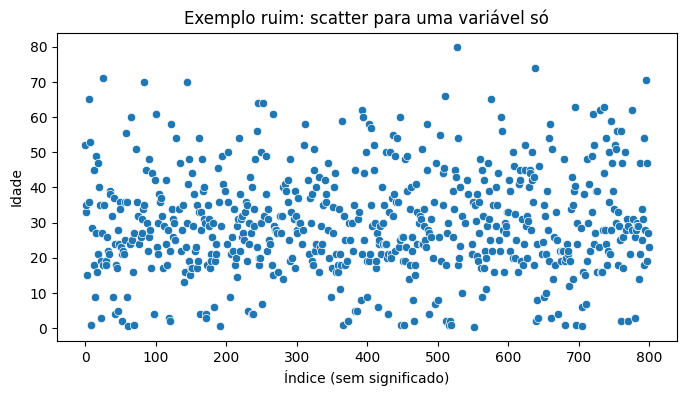

In [280]:
plt.figure(figsize=(8, 4))
df[["age", "fare", "sibsp", "parch"]].plot.hist(bins=20, alpha=0.5)
plt.title("Exemplo ruim: muitas variáveis no mesmo histograma")
plt.xlabel("Valores")
plt.ylabel("Contagem")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["age", "fare", "sibsp", "parch"]])
plt.title("Exemplo ruim: escalas muito diferentes no boxplot")
plt.xlabel("Variáveis")
plt.ylabel("Valores")
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(x=df.index, y="age", data=df)
plt.title("Exemplo ruim: scatter para uma variável só")
plt.xlabel("Índice (sem significado)")
plt.ylabel("Idade")
plt.show()


## 📌 3.2 Variáveis categóricas (nominais)

👉 Representam **categorias sem ordem** (ex.: `sex`, `embarked`, `embark_town`).

### Gráfico de barras (countplot)

Quando usar: **contar frequências** de cada categoria.


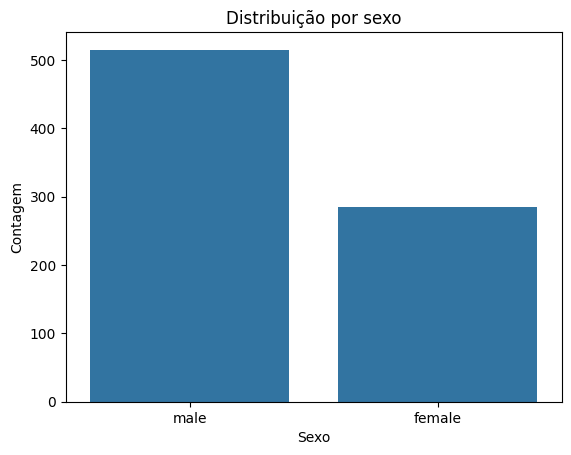

In [281]:
sns.countplot(x="sex", data=df)
plt.title("Distribuição por sexo")
plt.xlabel("Sexo")
plt.ylabel("Contagem")
plt.show()


### Comparar categorias com outro fator

Quando usar: **comparar categorias com outro grupo** (ex.: `sex` por `survived`).


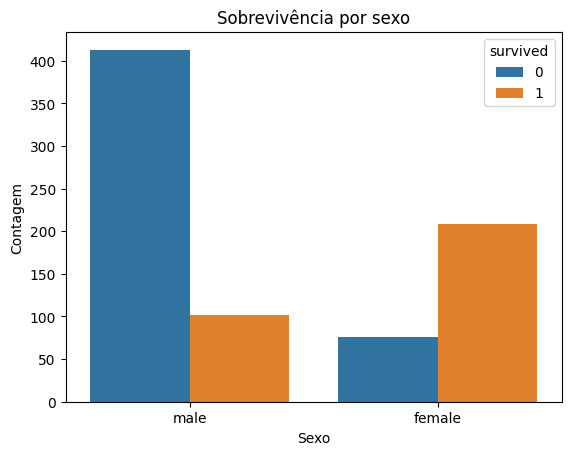

In [282]:
sns.countplot(x="sex", hue="survived", data=df)
plt.title("Sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Contagem")
plt.show()


### Exemplos ruins (para evitar)

- **Histograma de categorias codificadas** cria uma leitura enganosa.
- **Line plot com categorias** sugere continuidade que não existe.


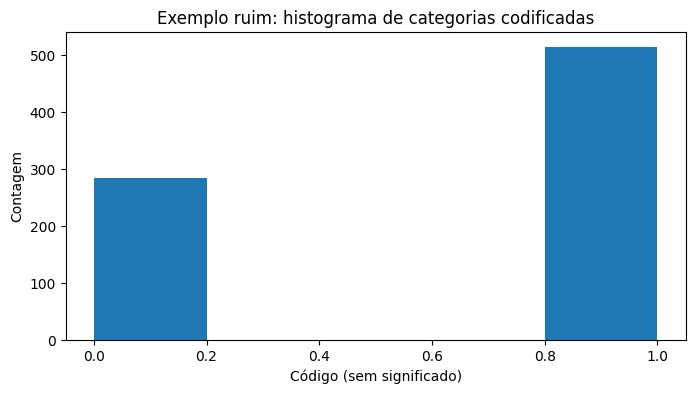

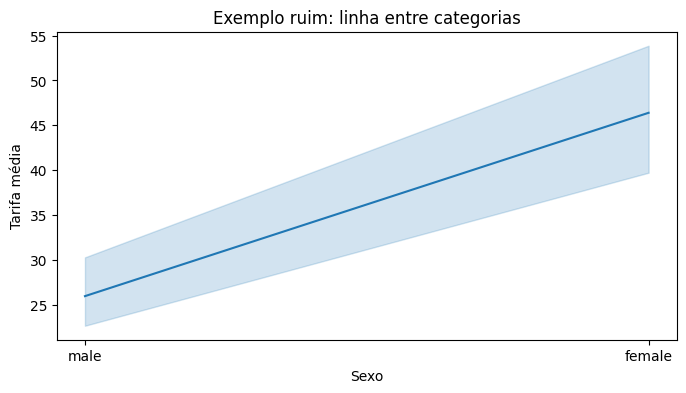

In [283]:
plt.figure(figsize=(8, 4))
df["sex"].astype("category").cat.codes.plot.hist(bins=5)
plt.title("Exemplo ruim: histograma de categorias codificadas")
plt.xlabel("Código (sem significado)")
plt.ylabel("Contagem")
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(x="sex", y="fare", data=df, estimator="mean")
plt.title("Exemplo ruim: linha entre categorias")
plt.xlabel("Sexo")
plt.ylabel("Tarifa média")
plt.show()


## 📌 3.3 Variáveis discretas ou ordinais

👉 São números com poucos níveis e, às vezes, **têm ordem** (ex.: `pclass`, `sibsp`, `parch`).

### Contagem por categoria (bar/countplot)

Quando usar: **quantas ocorrências** em cada nível.


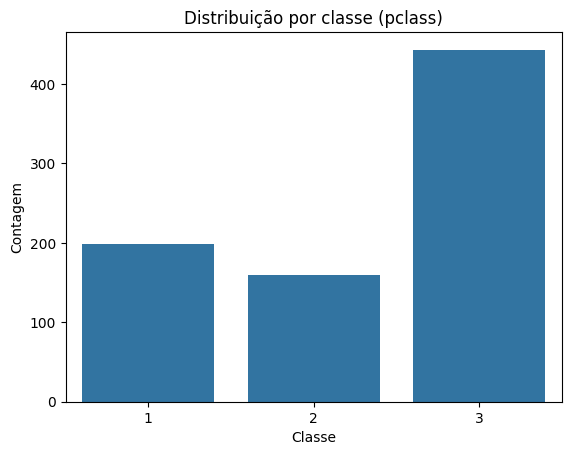

In [284]:
sns.countplot(x="pclass", data=df, order=sorted(df["pclass"].unique()))
plt.title("Distribuição por classe (pclass)")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


### Comparar nível ordinal com outro fator

Quando usar: **comparar a distribuição entre grupos**.


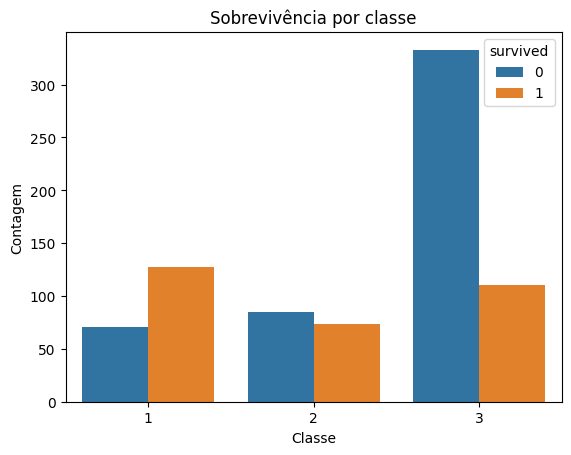

In [285]:
sns.countplot(x="pclass", hue="survived", data=df, order=sorted(df["pclass"].unique()))
plt.title("Sobrevivência por classe")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


### Exemplos ruins (para evitar)

- **Scatter para duas variáveis discretas** causa muita sobreposição e esconde frequência.
- **Histograma com muitos bins** em poucos níveis dá impressão falsa de continuidade.


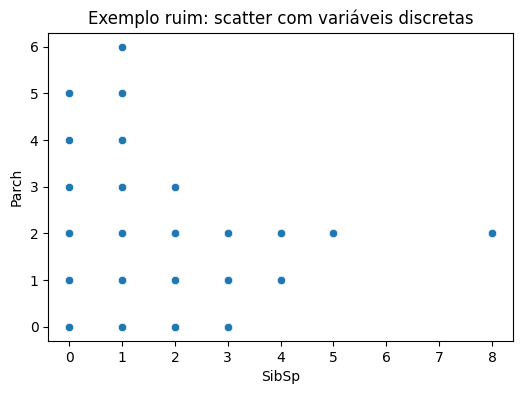

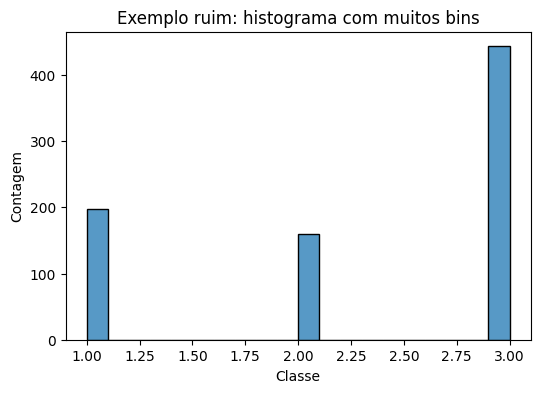

In [286]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x="sibsp", y="parch", data=df)
plt.title("Exemplo ruim: scatter com variáveis discretas")
plt.xlabel("SibSp")
plt.ylabel("Parch")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="pclass", bins=20)
plt.title("Exemplo ruim: histograma com muitos bins")
plt.xlabel("Classe")
plt.ylabel("Contagem")
plt.show()


## 📌 3.4 Variáveis temporais (datas/tempo)

👉 Representam **tempo** e precisam respeitar a ordem cronológica.

### Série temporal (linha)

Quando usar: **ver tendência ao longo do tempo**.


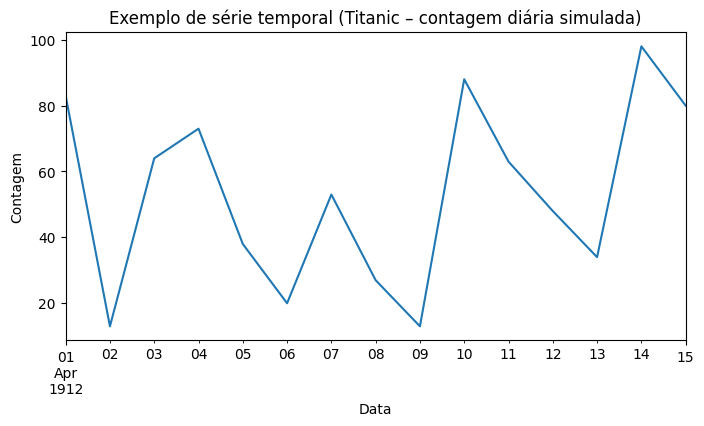

In [287]:
start = "1912-04-01"
end = "1912-04-15"
dates = pd.date_range(start, end, freq="D")

serie = pd.Series(
    data=np.random.randint(10, 100, size=len(dates)),
    index=dates,
)

plt.figure(figsize=(8, 4))
serie.plot()
plt.title("Exemplo de série temporal (Titanic – contagem diária simulada)")
plt.xlabel("Data")
plt.ylabel("Contagem")
plt.show()


### Exemplos ruins (para evitar)

- **Barplot com muitas datas** fica ilegível.
- **Usar índice no lugar de datas** esconde a ordem temporal real.


### Criando o DF para exemplos temporais


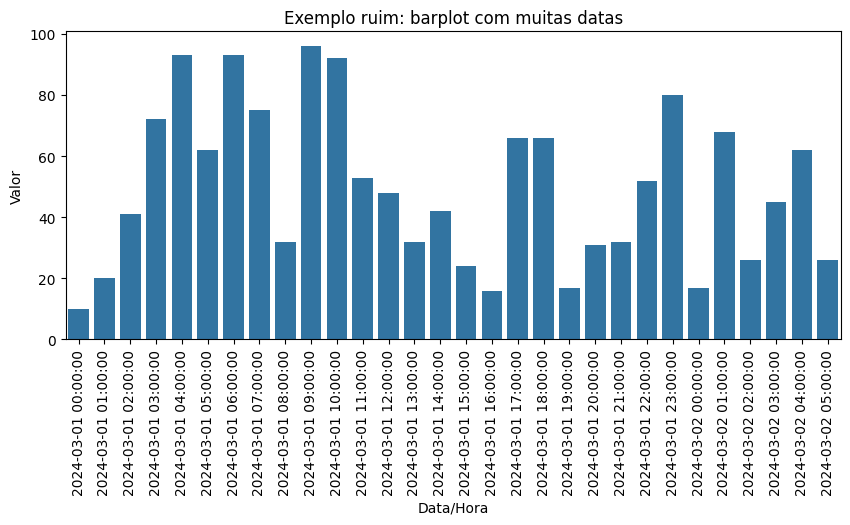

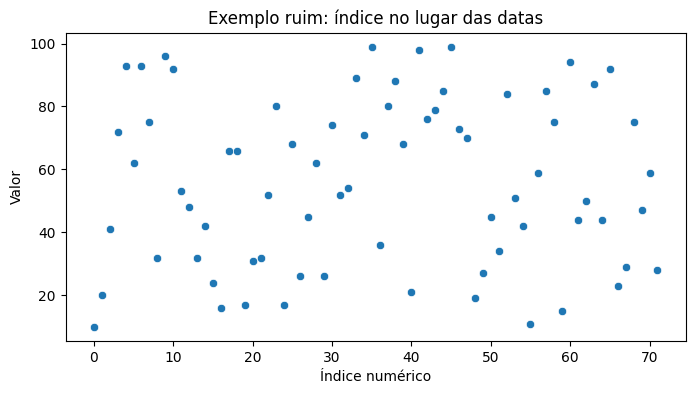

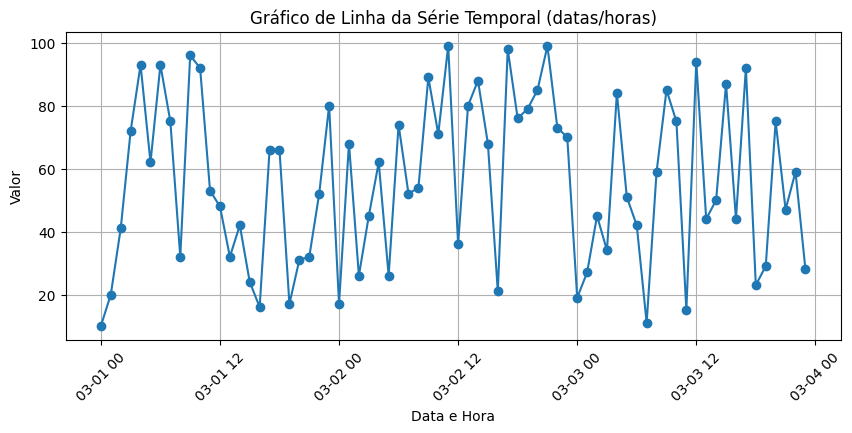

In [288]:
idx = pd.date_range(start="2024-03-01 00:00:00", periods=24 * 3, freq="H")
values = np.random.randint(10, 100, size=len(idx))
ts = pd.Series(values, index=idx)

df_time = ts.reset_index().rename(columns={"index": "date", 0: "value"})

plt.figure(figsize=(10, 4))
subset = df_time.head(30)
sns.barplot(x="date", y="value", data=subset)
plt.title("Exemplo ruim: barplot com muitas datas")
plt.xlabel("Data/Hora")
plt.ylabel("Valor")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(8, 4))
sns.scatterplot(x=df_time.head(100).index, y="value", data=df_time.head(100))
plt.title("Exemplo ruim: índice no lugar das datas")
plt.xlabel("Índice numérico")
plt.ylabel("Valor")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(ts.index, ts.values, marker="o", linestyle="-")
plt.title("Gráfico de Linha da Série Temporal (datas/horas)")
plt.xlabel("Data e Hora")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


## 📌 3.6 Gráfico de pizza (por que evitar)

👉 O gráfico de pizza **dificulta comparar ângulos** e **não mostra bem diferenças pequenas**.

Quando usar: **raramente**, e só com poucas categorias (2–3) e diferenças grandes.

Melhor alternativa: **gráfico de barras**.


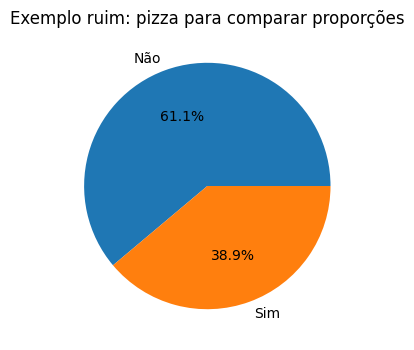

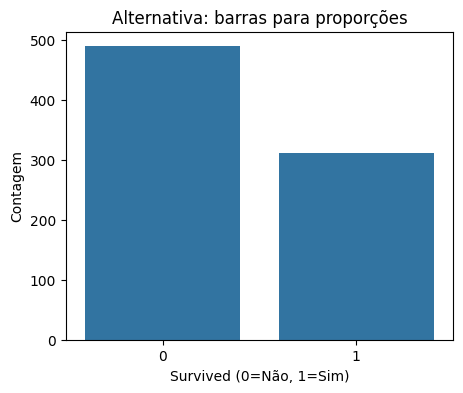

In [289]:
counts = df["survived"].value_counts().sort_index()
plt.figure(figsize=(4, 4))
plt.pie(counts, labels=["Não", "Sim"], autopct="%1.1f%%")
plt.title("Exemplo ruim: pizza para comparar proporções")
plt.show()

plt.figure(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.title("Alternativa: barras para proporções")
plt.xlabel("Survived (0=Não, 1=Sim)")
plt.ylabel("Contagem")
plt.show()


## 📌 3.7 Gráficos diferentes e úteis

Abaixo estão alguns gráficos menos “óbvios”, mas muito úteis no dia a dia.

### Violinplot

Mostra **distribuição + densidade** e ajuda a comparar grupos.


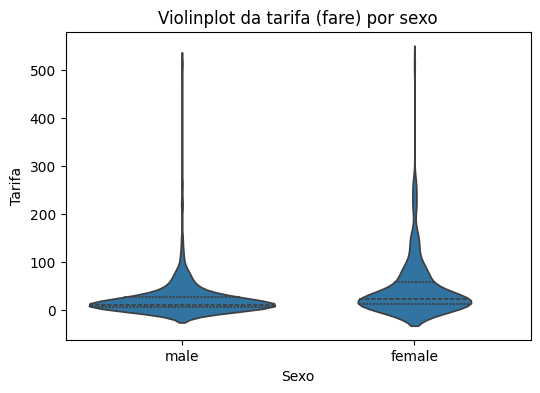

In [290]:
plt.figure(figsize=(6, 4))
sns.violinplot(x="sex", y="fare", data=df, inner="quartile")
plt.title("Violinplot da tarifa (fare) por sexo")
plt.xlabel("Sexo")
plt.ylabel("Tarifa")
plt.show()


### Heatmap de correlação

Bom para **resumir relações** entre variáveis numéricas.


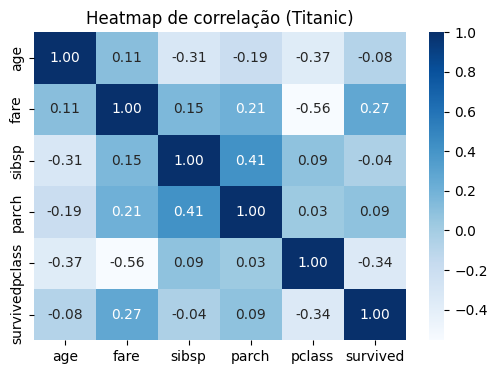

In [291]:
num_cols = ["age", "fare", "sibsp", "parch", "pclass", "survived"]
corr = df[num_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap de correlação (Titanic)")
plt.show()


## 📌 3.8 Gráfico de relógio

Usa a **série temporal criada** para mostrar o padrão por hora do dia em formato de relógio.


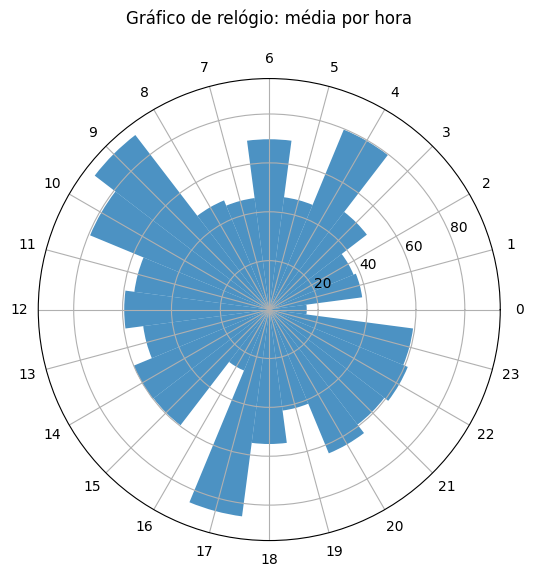

In [292]:
if "ts" not in locals():
    idx = pd.date_range(start="2024-03-01 00:00:00", periods=24 * 3, freq="H")
    values = np.random.randint(10, 100, size=len(idx))
    ts = pd.Series(values, index=idx)

hourly = ts.groupby(ts.index.hour).mean().reindex(range(24), fill_value=0)
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)
ax.bar(angles, hourly.values, width=2 * np.pi / 24, alpha=0.8)

ax.set_xticks(angles)
ax.set_xticklabels([str(h) for h in range(24)])
ax.set_title("Gráfico de relógio: média por hora", pad=20)
plt.show()


## Conclusao

Graficos nao sao magia. Eles sao ferramentas para contar uma historia com dados de forma clara e objetiva.

Eles ajudam a:
- **resumir padroes que passam despercebidos em tabelas**
- **mostrar tendencias e comparacoes com clareza**
- **tornar a mensagem mais facil de entender e lembrar**
- **explicar nao so o que aconteceu, mas por que isso importa**

Resumo rapido:
- Numericas continuas → histograma, boxplot, violin.
- Categoricas → barras (countplot) e comparacoes com `hue`.
- Ordinais/discretas → barras ordenadas e comparacoes por grupo.
- Temporais → linhas e series.
- Binarias → barras simples.

**Storytelling e conectar cada grafico a uma pergunta real, com comeco, meio e fim.**
